In [101]:
!pip install requests pandas sqlalchemy matplotlib scipy

In [102]:
import requests
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import scipy.stats as stats
from datetime import datetime

In [103]:
LASTFM_API_KEY = "21e40acedad2dac2dabf4fc81311f85a"

GROUP_A = {
    'Drake': '2010s',
    'Rihanna': '2010s',
    'Kanye West': '2010s',
    'Beyonce': '2010s',
    'Eminem': '2010s'
}

GROUP_B = {
    'Taylor Swift': '2020s',
    'Bad Bunny': '2020s',
    'The Weeknd': '2020s',
    'Olivia Rodrigo': '2020s',
    'Doja Cat': '2020s'
}

ALL_ARTISTS = {**GROUP_A, **GROUP_B}
print("Config loaded!")

Config loaded!


In [104]:
def get_artist_data(artist_name, era):
    url = "http://ws.audioscrobbler.com/2.0/"
    params = {
        'method': 'artist.getinfo',
        'artist': artist_name,
        'api_key': LASTFM_API_KEY,
        'format': 'json'
    }
    response = requests.get(url, params=params)
    data = response.json()

    if 'artist' in data:
        artist = data['artist']
        return {
            'artist': artist_name,
            'era': era,
            'listeners': int(artist['stats'].get('listeners', 0)),
            'playcount': int(artist['stats'].get('playcount', 0)),
            'tags': ', '.join([t['name'] for t in artist['tags']['tag'][:3]])
        }
    return None

artist_data = []
for artist, era in ALL_ARTISTS.items():
    print(f"Extracting {artist}...")
    data = get_artist_data(artist, era)
    if data:
        artist_data.append(data)
        print(f"  Listeners: {data['listeners']:,} | Playcount: {data['playcount']:,}")

print(f"\nTotal artists extracted: {len(artist_data)}")

Extracting Drake...
  Listeners: 6,676,242 | Playcount: 1,143,686,752
Extracting Rihanna...
  Listeners: 8,241,239 | Playcount: 593,160,747
Extracting Kanye West...
  Listeners: 7,895,595 | Playcount: 1,500,945,313
Extracting Beyonce...
  Listeners: 873,028 | Playcount: 26,696,258
Extracting Eminem...
  Listeners: 7,753,892 | Playcount: 564,475,263
Extracting Taylor Swift...
  Listeners: 5,893,743 | Playcount: 3,637,801,098
Extracting Bad Bunny...
  Listeners: 2,527,632 | Playcount: 394,936,112
Extracting The Weeknd...
  Listeners: 5,266,212 | Playcount: 1,106,663,004
Extracting Olivia Rodrigo...
  Listeners: 3,054,063 | Playcount: 548,207,629
Extracting Doja Cat...
  Listeners: 3,589,811 | Playcount: 461,740,857

Total artists extracted: 10


In [105]:
def get_top_tracks(artist_name, era):
    url = "http://ws.audioscrobbler.com/2.0/"
    params = {
        'method': 'artist.gettoptracks',
        'artist': artist_name,
        'api_key': LASTFM_API_KEY,
        'format': 'json',
        'limit': 10
    }
    response = requests.get(url, params=params)
    data = response.json()

    tracks = []
    if 'toptracks' in data:
        for track in data['toptracks']['track']:
            tracks.append({
                'artist': artist_name,
                'era': era,
                'track_name': track.get('name', 'Unknown'),
                'track_playcount': int(track.get('playcount', 0)),
                'track_listeners': int(track.get('listeners', 0))
            })
    return tracks

all_tracks = []
for artist, era in ALL_ARTISTS.items():
    print(f"Extracting top tracks for {artist}...")
    tracks = get_top_tracks(artist, era)
    all_tracks.extend(tracks)
    print(f"  Got {len(tracks)} tracks!")

print(f"\nTotal tracks extracted: {len(all_tracks)}")

Extracting top tracks for Drake...
  Got 10 tracks!
Extracting top tracks for Rihanna...
  Got 10 tracks!
Extracting top tracks for Kanye West...
  Got 10 tracks!
Extracting top tracks for Beyonce...
  Got 10 tracks!
Extracting top tracks for Eminem...
  Got 10 tracks!
Extracting top tracks for Taylor Swift...
  Got 10 tracks!
Extracting top tracks for Bad Bunny...
  Got 10 tracks!
Extracting top tracks for The Weeknd...
  Got 10 tracks!
Extracting top tracks for Olivia Rodrigo...
  Got 10 tracks!
Extracting top tracks for Doja Cat...
  Got 10 tracks!

Total tracks extracted: 100


In [106]:
df_artists = pd.DataFrame(artist_data)
df_tracks = pd.DataFrame(all_tracks)

df = df_tracks.merge(df_artists, on=['artist', 'era'], how='left')
df = df.dropna()

df['popularity_score'] = (
    df['track_playcount'] / df['track_playcount'].max() * 100
).round(2)

# Categorize popularity for A/B test
df['popularity_group'] = df['popularity_score'].apply(
    lambda x: 'High' if x >= 50 else 'Low'
)

# Add timestamp
df['extracted_at'] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

print("Data transformed!")
print(df.head())

Data transformed!
  artist    era       track_name  track_playcount  track_listeners  listeners  \
0  Drake  2010s        One Dance         22362200          1933064    6676242   
1  Drake  2010s  Best I Ever Had         12367516          1790107    6676242   
2  Drake  2010s     Passionfruit         27756068          1588964    6676242   
3  Drake  2010s       God's Plan         14532793          1446358    6676242   
4  Drake  2010s    Hotline Bling         12422905          1422969    6676242   

    playcount               tags  popularity_score popularity_group  \
0  1143686752  Hip-Hop, rap, rnb             45.91              Low   
1  1143686752  Hip-Hop, rap, rnb             25.39              Low   
2  1143686752  Hip-Hop, rap, rnb             56.99             High   
3  1143686752  Hip-Hop, rap, rnb             29.84              Low   
4  1143686752  Hip-Hop, rap, rnb             25.51              Low   

          extracted_at  
0  2026-03-28 02:35:53  
1  2026-03-28 02:3

In [107]:
engine = create_engine('sqlite:///music_pipeline.db')
df.to_sql('tracks', engine, if_exists='replace', index=False)
print(f"Loaded {len(df)} rows into database!")

Loaded 100 rows into database!


In [108]:
era_summary = pd.read_sql_query("""
    SELECT
        era,
        ROUND(AVG(popularity_score), 2) as avg_popularity,
        ROUND(AVG(listeners), 0) as avg_listeners,
        ROUND(AVG(playcount), 0) as avg_playcount,
        COUNT(*) as total_tracks
    FROM tracks
    GROUP BY era
    ORDER BY avg_popularity DESC
""", engine)

print("=== ERA COMPARISON ===")
print(era_summary)

=== ERA COMPARISON ===
     era  avg_popularity  avg_listeners  avg_playcount  total_tracks
0  2020s           47.53      4066292.0   1.229870e+09            50
1  2010s           34.41      6287999.0   7.657929e+08            50


In [109]:
artist_summary = pd.read_sql_query("""
    SELECT
        artist,
        era,
        ROUND(AVG(popularity_score), 2) as avg_popularity,
        ROUND(AVG(listeners), 0) as avg_listeners,
        COUNT(*) as total_tracks
    FROM tracks
    GROUP BY artist, era
    ORDER BY avg_popularity DESC
""", engine)

print("=== ARTIST RANKING ===")
print(artist_summary)

=== ARTIST RANKING ===
           artist    era  avg_popularity  avg_listeners  total_tracks
0    Taylor Swift  2020s           62.66      5893743.0            10
1      The Weeknd  2020s           56.95      5266212.0            10
2      Kanye West  2010s           56.27      7895595.0            10
3  Olivia Rodrigo  2020s           55.76      3054063.0            10
4        Doja Cat  2020s           40.87      3589811.0            10
5         Rihanna  2010s           36.06      8241239.0            10
6           Drake  2010s           30.87      6676242.0            10
7          Eminem  2010s           26.63      7753892.0            10
8         Beyonce  2010s           22.22       873028.0            10
9       Bad Bunny  2020s           21.42      2527632.0            10


In [110]:
group_a = df[df['era'] == '2010s']['popularity_score']
group_b = df[df['era'] == '2020s']['popularity_score']

t_stat, p_value = stats.ttest_ind(group_a, group_b)

print("=== A/B TEST RESULTS ===")
print(f"2010s Average Popularity Score: {group_a.mean():.2f}")
print(f"2020s Average Popularity Score: {group_b.mean():.2f}")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.3f}")
print()
if p_value < 0.05:
    print("RESULT: The difference IS statistically significant!")
    print("One era is genuinely more popular than the other.")
else:
    print("RESULT: The difference is NOT statistically significant.")
    print("Both eras have similar popularity levels.")

=== A/B TEST RESULTS ===
2010s Average Popularity Score: 34.41
2020s Average Popularity Score: 47.53
T-statistic: -3.548
P-value: 0.001

RESULT: The difference IS statistically significant!
One era is genuinely more popular than the other.


In [111]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['axes.titlecolor'] = '#9d174d'
plt.rcParams['axes.labelcolor'] = '#6b21a8'
plt.rcParams['xtick.color'] = '#6b21a8'
plt.rcParams['ytick.color'] = '#6b21a8'
plt.rcParams['figure.facecolor'] = '#fdf4ff'
plt.rcParams['axes.facecolor'] = '#fdf4ff'

print("Font settings applied!")

Font settings applied!


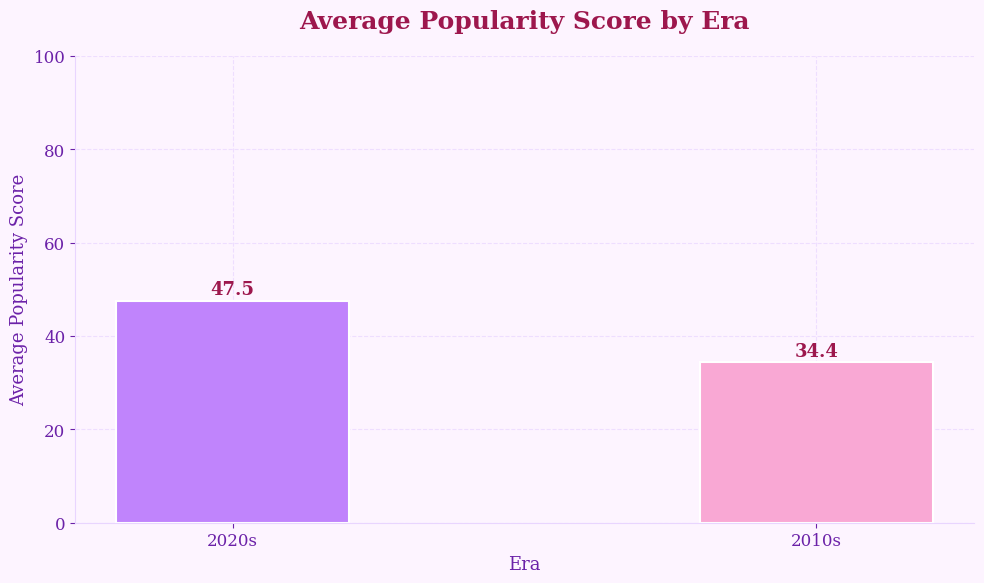

In [112]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(era_summary['era'], era_summary['avg_popularity'],
              color=['#c084fc', '#f9a8d4'], width=0.4,
              edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}', ha='center', va='bottom',
            fontsize=13, fontweight='bold', color='#9d174d')

ax.set_title('Average Popularity Score by Era',
             fontsize=18, fontweight='bold',
             color='#9d174d', pad=20)
ax.set_xlabel('Era', fontsize=13, color='#6b21a8')
ax.set_ylabel('Average Popularity Score', fontsize=13, color='#6b21a8')
ax.set_ylim(0, 100)
ax.tick_params(colors='#6b21a8')
ax.set_facecolor('#fdf4ff')
fig.patch.set_facecolor('#fdf4ff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e9d5ff')
ax.spines['bottom'].set_color('#e9d5ff')
ax.yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('popularity_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

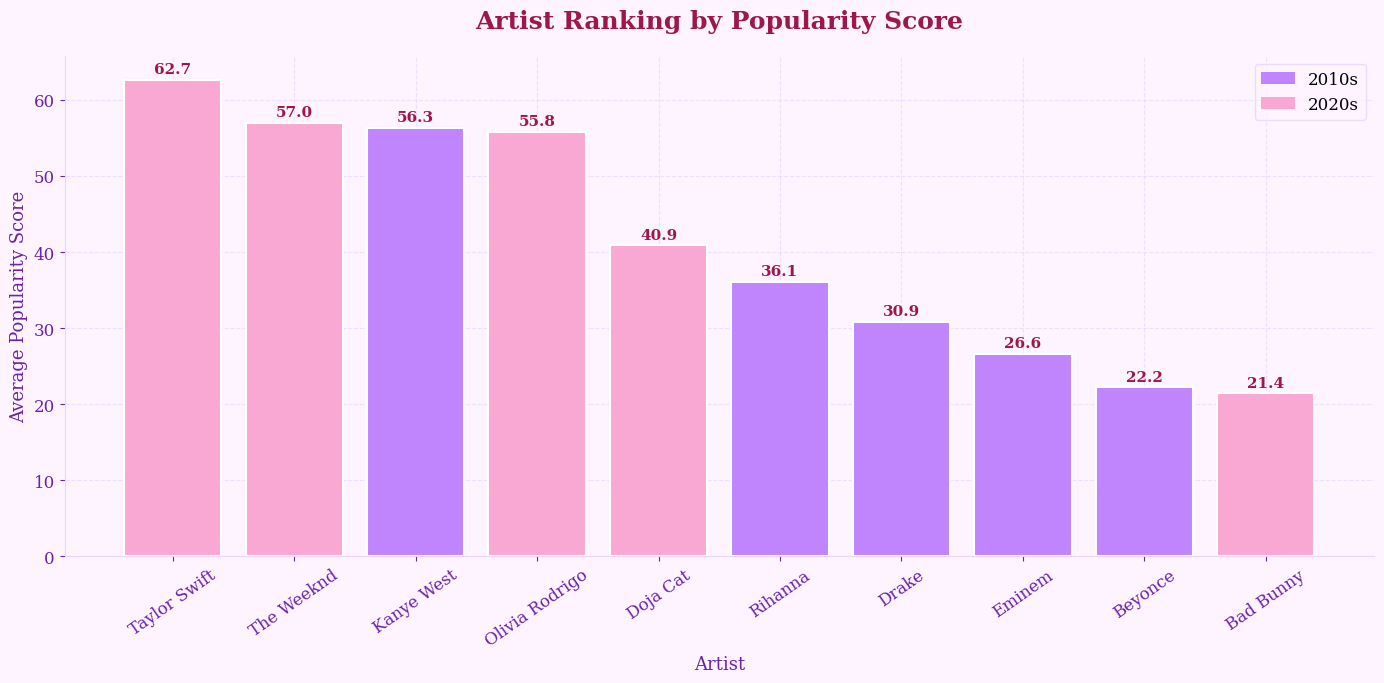

In [113]:
colors = artist_summary['era'].map({'2010s': '#c084fc', '2020s': '#f9a8d4'})

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(artist_summary['artist'], artist_summary['avg_popularity'],
              color=colors, edgecolor='white', linewidth=1.5)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#9d174d')

ax.set_title('Artist Ranking by Popularity Score',
             fontsize=18, fontweight='bold',
             color='#9d174d', pad=20)
ax.set_xlabel('Artist', fontsize=13, color='#6b21a8')
ax.set_ylabel('Average Popularity Score', fontsize=13, color='#6b21a8')
ax.tick_params(axis='x', rotation=35, colors='#6b21a8')
ax.tick_params(axis='y', colors='#6b21a8')
ax.set_facecolor('#fdf4ff')
fig.patch.set_facecolor('#fdf4ff')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#e9d5ff')
ax.spines['bottom'].set_color('#e9d5ff')
ax.yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#c084fc', label='2010s'),
    Patch(facecolor='#f9a8d4', label='2020s')
]
ax.legend(handles=legend_elements, fontsize=12,
          facecolor='#fdf4ff', edgecolor='#e9d5ff')

plt.tight_layout()
plt.savefig('artist_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

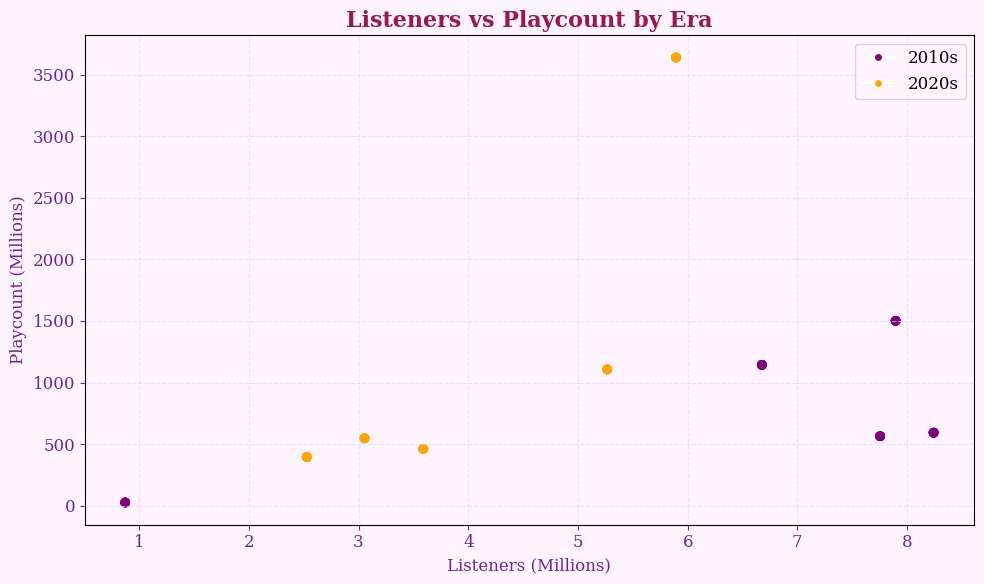

In [114]:
colors = df['era'].map({'2010s': 'purple', '2020s': 'orange'})

plt.figure(figsize=(10, 6))
plt.scatter(
    df['listeners'] / 1000000,
    df['playcount'] / 1000000,
    c=colors, alpha=0.6
)
plt.title('Listeners vs Playcount by Era')
plt.xlabel('Listeners (Millions)')
plt.ylabel('Playcount (Millions)')
plt.legend(handles=[
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='purple', label='2010s'),
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor='orange', label='2020s')
])
plt.tight_layout()
plt.savefig('listeners_vs_playcount.png')
plt.show()

In [115]:
print("=== DEEP A/B TEST ANALYSIS ===\n")

# Test 1: Popularity Score
group_a_pop = df[df['era'] == '2010s']['popularity_score']
group_b_pop = df[df['era'] == '2020s']['popularity_score']
t1, p1 = stats.ttest_ind(group_a_pop, group_b_pop)

# Test 2: Raw Listeners
group_a_listeners = df[df['era'] == '2010s']['listeners']
group_b_listeners = df[df['era'] == '2020s']['listeners']
t2, p2 = stats.ttest_ind(group_a_listeners, group_b_listeners)

# Test 3: Raw Playcount
group_a_plays = df[df['era'] == '2010s']['track_playcount']
group_b_plays = df[df['era'] == '2020s']['track_playcount']
t3, p3 = stats.ttest_ind(group_a_plays, group_b_plays)

results = pd.DataFrame({
    'Metric': ['Popularity Score', 'Listeners', 'Playcount'],
    '2010s Average': [
        round(group_a_pop.mean(), 2),
        round(group_a_listeners.mean(), 0),
        round(group_a_plays.mean(), 0)
    ],
    '2020s Average': [
        round(group_b_pop.mean(), 2),
        round(group_b_listeners.mean(), 0),
        round(group_b_plays.mean(), 0)
    ],
    'P-Value': [round(p1, 3), round(p2, 3), round(p3, 3)],
    'Significant?': [
        'Yes' if p1 < 0.05 else 'No',
        'Yes' if p2 < 0.05 else 'No',
        'Yes' if p3 < 0.05 else 'No'
    ]
})

print(results.to_string(index=False))

=== DEEP A/B TEST ANALYSIS ===

          Metric  2010s Average  2020s Average  P-Value Significant?
Popularity Score          34.41          47.53    0.001          Yes
       Listeners     6287999.00     4066292.00    0.000          Yes
       Playcount    16759277.00    23151070.00    0.001          Yes


In [116]:
# Cohen's D
def cohens_d(group1, group2):
    diff = group1.mean() - group2.mean()
    pooled_std = ((group1.std() ** 2 + group2.std() ** 2) / 2) ** 0.5
    return round(diff / pooled_std, 3)

d_popularity = cohens_d(group_a_pop, group_b_pop)
d_listeners = cohens_d(group_a_listeners, group_b_listeners)
d_plays = cohens_d(group_a_plays, group_b_plays)

def interpret_d(d):
    d = abs(d)
    if d < 0.2: return "Tiny effect"
    elif d < 0.5: return "Small effect"
    elif d < 0.8: return "Medium effect"
    else: return "Large effect"

print("=== EFFECT SIZE ANALYSIS (Cohen's D) ===\n")
print(f"Popularity Score: d={d_popularity} → {interpret_d(d_popularity)}")
print(f"Listeners:        d={d_listeners} → {interpret_d(d_listeners)}")
print(f"Playcount:        d={d_plays} → {interpret_d(d_plays)}")
print()
print("Cohen's D scale:")
print("  < 0.2 = Tiny   | 0.2-0.5 = Small")
print("  0.5-0.8 = Medium | > 0.8 = Large")

=== EFFECT SIZE ANALYSIS (Cohen's D) ===

Popularity Score: d=-0.71 → Medium effect
Listeners:        d=1.021 → Large effect
Playcount:        d=-0.71 → Medium effect

Cohen's D scale:
  < 0.2 = Tiny   | 0.2-0.5 = Small
  0.5-0.8 = Medium | > 0.8 = Large


In [117]:
print("=== WHICH ARTISTS DRIVE THE DIFFERENCE? ===\n")

artist_ab = df.groupby(['artist', 'era']).agg(
    avg_popularity=('popularity_score', 'mean'),
    avg_listeners=('listeners', 'mean'),
    total_tracks=('track_name', 'count')
).round(2).reset_index()

# Artists sorted by popularity
artist_ab = artist_ab.sort_values('avg_popularity', ascending=False)

# Specifies top and bottom performers
artist_ab['performance'] = artist_ab['avg_popularity'].apply(
    lambda x: 'Top Performer' if x >= 50 else ('Below Average' if x < 25 else 'Average')
)

print(artist_ab.to_string(index=False))

=== WHICH ARTISTS DRIVE THE DIFFERENCE? ===

        artist   era  avg_popularity  avg_listeners  total_tracks   performance
  Taylor Swift 2020s           62.66      5893743.0            10 Top Performer
    The Weeknd 2020s           56.95      5266212.0            10 Top Performer
    Kanye West 2010s           56.27      7895595.0            10 Top Performer
Olivia Rodrigo 2020s           55.76      3054063.0            10 Top Performer
      Doja Cat 2020s           40.87      3589811.0            10       Average
       Rihanna 2010s           36.06      8241239.0            10       Average
         Drake 2010s           30.87      6676242.0            10       Average
        Eminem 2010s           26.62      7753892.0            10       Average
       Beyonce 2010s           22.22       873028.0            10 Below Average
     Bad Bunny 2020s           21.42      2527632.0            10 Below Average


In [118]:
import numpy as np

def confidence_interval(group, confidence=0.95):
    n = len(group)
    mean = group.mean()
    se = stats.sem(group)
    margin = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return round(mean - margin, 2), round(mean + margin, 2)

ci_a = confidence_interval(group_a_pop)
ci_b = confidence_interval(group_b_pop)

print("=== CONFIDENCE INTERVALS (95%) ===\n")
print(f"2010s: {ci_a[0]} to {ci_a[1]}")
print(f"2020s: {ci_b[0]} to {ci_b[1]}")
print()
if ci_a[1] < ci_b[0] or ci_b[1] < ci_a[0]:
    print("Intervals don't overlap — strong evidence the difference is real!")
else:
    print("Intervals overlap — difference may be weaker than it appears.")

=== CONFIDENCE INTERVALS (95%) ===

2010s: 29.94 to 38.87
2020s: 41.59 to 53.47

Intervals don't overlap — strong evidence the difference is real!


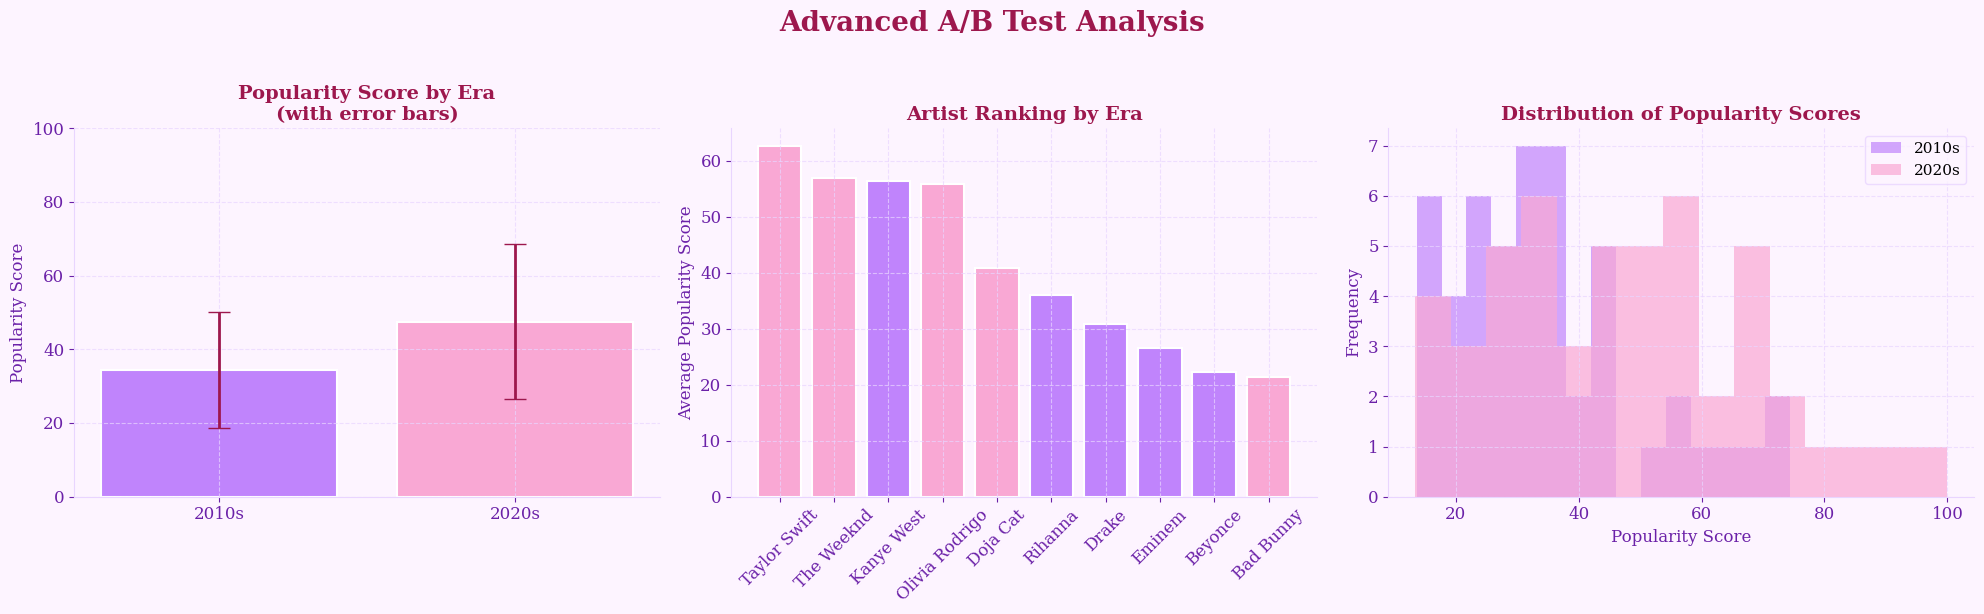

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#fdf4ff')

era_stats = df.groupby('era')['popularity_score'].agg(['mean', 'std']).reset_index()
axes[0].bar(era_stats['era'], era_stats['mean'],
            yerr=era_stats['std'],
            color=['#c084fc', '#f9a8d4'],
            capsize=8, edgecolor='white', linewidth=1.5,
            error_kw={'ecolor': '#9d174d', 'elinewidth': 2})
axes[0].set_title('Popularity Score by Era\n(with error bars)',
                  fontsize=14, fontweight='bold', color='#9d174d')
axes[0].set_ylabel('Popularity Score', color='#6b21a8')
axes[0].set_ylim(0, 100)
axes[0].set_facecolor('#fdf4ff')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('#e9d5ff')
axes[0].spines['bottom'].set_color('#e9d5ff')
axes[0].yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)
axes[0].tick_params(colors='#6b21a8')

colors = artist_ab['era'].map({'2010s': '#c084fc', '2020s': '#f9a8d4'})
axes[1].bar(artist_ab['artist'], artist_ab['avg_popularity'],
            color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Artist Ranking by Era',
                  fontsize=14, fontweight='bold', color='#9d174d')
axes[1].set_ylabel('Average Popularity Score', color='#6b21a8')
axes[1].tick_params(axis='x', rotation=45, colors='#6b21a8')
axes[1].tick_params(axis='y', colors='#6b21a8')
axes[1].set_facecolor('#fdf4ff')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('#e9d5ff')
axes[1].spines['bottom'].set_color('#e9d5ff')
axes[1].yaxis.grid(True, color='#e9d5ff', linestyle='--', alpha=0.7)

df[df['era'] == '2010s']['popularity_score'].hist(
    bins=15, alpha=0.7, color='#c084fc', label='2010s', ax=axes[2])
df[df['era'] == '2020s']['popularity_score'].hist(
    bins=15, alpha=0.7, color='#f9a8d4', label='2020s', ax=axes[2])
axes[2].set_title('Distribution of Popularity Scores',
                  fontsize=14, fontweight='bold', color='#9d174d')
axes[2].set_xlabel('Popularity Score', color='#6b21a8')
axes[2].set_ylabel('Frequency', color='#6b21a8')
axes[2].legend(fontsize=11, facecolor='#fdf4ff', edgecolor='#e9d5ff')
axes[2].set_facecolor('#fdf4ff')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].spines['left'].set_color('#e9d5ff')
axes[2].spines['bottom'].set_color('#e9d5ff')
axes[2].tick_params(colors='#6b21a8')

plt.suptitle('Advanced A/B Test Analysis',
             fontsize=20, fontweight='bold', color='#9d174d', y=1.02)
plt.tight_layout()
plt.savefig('advanced_ab_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [120]:
def style_table(df, title=""):
    df = df.copy()

    df = df.round(2)

    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    df.columns = [col.replace('_', ' ').title() for col in df.columns]
    numeric_cols_renamed = [col.replace('_', ' ').title() for col in numeric_cols]

    for col in numeric_cols_renamed:
        if col in df.columns:
            if df[col].max() > 1000:
                df[col] = df[col].apply(lambda x: f'{x:,.0f}')
            elif df[col].max() <= 100:
                df[col] = df[col].apply(lambda x: f'{x:.2f}')
            else:
                df[col] = df[col].apply(lambda x: f'{x:,.0f}')

    from IPython.display import display, HTML
    display(HTML(f'<h3 style="color:#6b21a8; font-size:18px; font-weight:bold; letter-spacing:1px; margin-bottom:8px; padding:8px 0;">{title}</h3>'))

    styled = df.style\
        .hide(axis='index')\
        .set_properties(**{
            'font-size': '13px',
            'border': '1px solid #e9d5ff',
            'text-align': 'center',
            'padding': '10px 16px',
            'background-color': '#fdf4ff',
            'color': '#3b0764'
        })\
        .set_table_styles([
            {'selector': 'th', 'props': [
                ('background-color', '#c084fc'),
                ('color', 'white'),
                ('font-size', '13px'),
                ('font-weight', 'bold'),
                ('padding', '10px 16px'),
                ('border', '1px solid #e9d5ff'),
                ('letter-spacing', '0.5px')
            ]},
            {'selector': 'tr:nth-child(even) td', 'props': [
                ('background-color', '#f3e8ff'),
            ]},
            {'selector': 'tr:hover td', 'props': [
                ('background-color', '#f9a8d4 !important'),
            ]}
        ])
    return styled

display(style_table(era_summary, "Era Comparison"))
display(style_table(artist_summary, "Artist Ranking"))

Era,Avg Popularity,Avg Listeners,Avg Playcount,Total Tracks
2020s,47.53,"4,066,292","1,229,869,740",50.00
2010s,34.41,"6,287,999","765,792,867",50.00


Artist,Era,Avg Popularity,Avg Listeners,Total Tracks
Taylor Swift,2020s,62.66,"5,893,743",10.00
The Weeknd,2020s,56.95,"5,266,212",10.00
Kanye West,2010s,56.27,"7,895,595",10.00
Olivia Rodrigo,2020s,55.76,"3,054,063",10.00
Doja Cat,2020s,40.87,"3,589,811",10.00
Rihanna,2010s,36.06,"8,241,239",10.00
Drake,2010s,30.87,"6,676,242",10.00
Eminem,2010s,26.63,"7,753,892",10.00
Beyonce,2010s,22.22,"873,028",10.00
Bad Bunny,2020s,21.42,"2,527,632",10.00
